In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [43]:
df = pd.read_csv('Housing.csv')

In [44]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [46]:
df.shape

(545, 13)

In [47]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

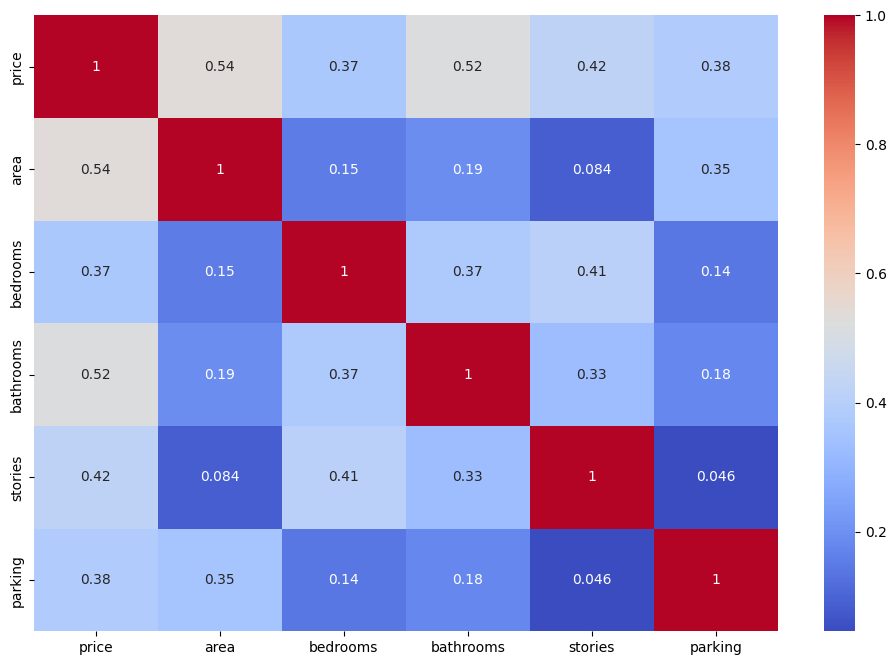

In [49]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object'])
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [50]:
log_transform_cols = []
zero_threshold = 0.75
for col in numeric_cols:
    value_counts = df[col].value_counts(normalize=True)
    if 0 in value_counts.index and value_counts[0] > zero_threshold:
        continue
    skewness = df[col].skew()
    if abs(skewness) > 0.5:
        log_transform_cols.append(col)
        print(f"Column: {col}, Skewness: {skewness:.2f}")
print(log_transform_cols)

Column: price, Skewness: 1.21
Column: area, Skewness: 1.32
Column: bathrooms, Skewness: 1.59
Column: stories, Skewness: 1.08
Column: parking, Skewness: 0.84
['price', 'area', 'bathrooms', 'stories', 'parking']


Column: price, Lower Bound: -35000.00, Upper Bound: 9205000.00
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64
price outliers: 2.75%


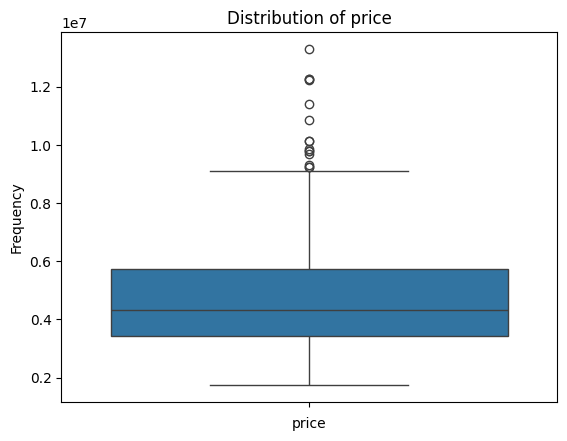

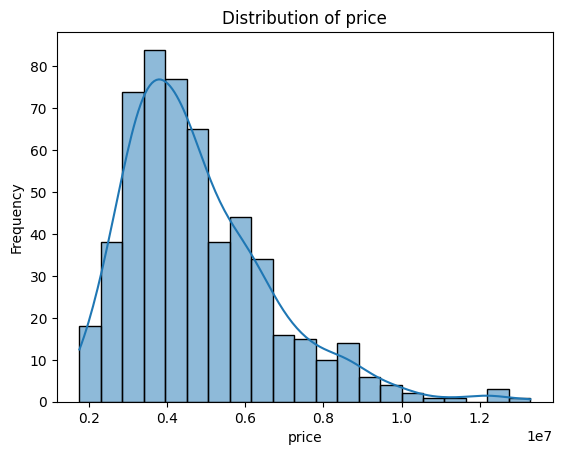

Column: area, Lower Bound: -540.00, Upper Bound: 10500.00
count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64
area outliers: 2.2%


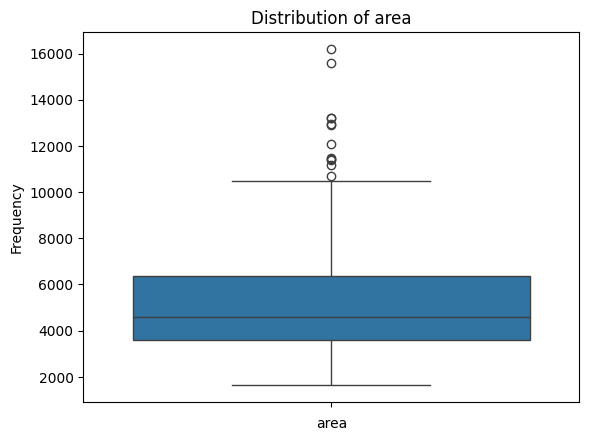

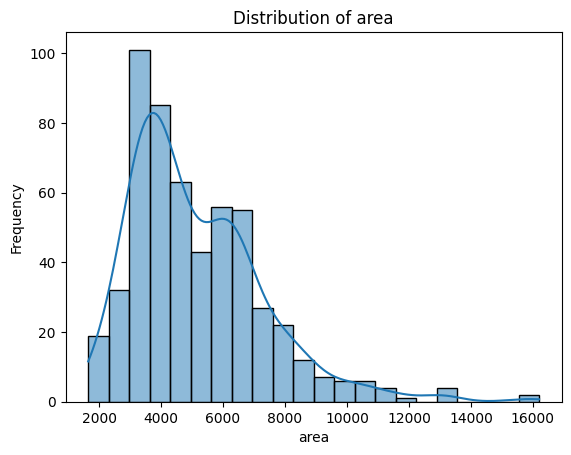

Column: bathrooms, Lower Bound: -0.50, Upper Bound: 3.50
count    545.000000
mean       1.286239
std        0.502470
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        4.000000
Name: bathrooms, dtype: float64
bathrooms outliers: 0.18%


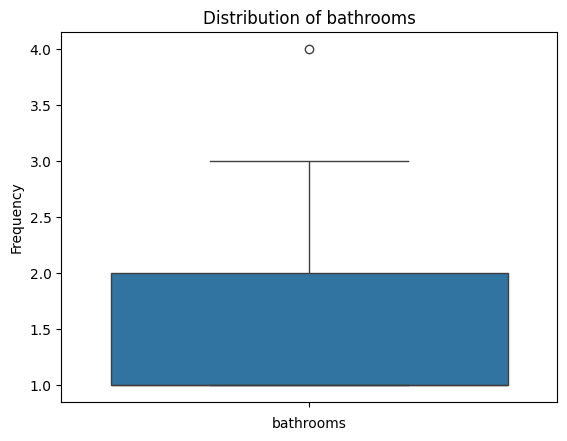

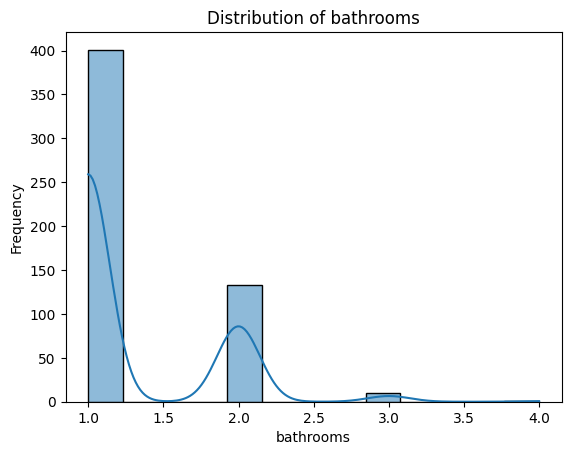

Column: stories, Lower Bound: -0.50, Upper Bound: 3.50
count    545.000000
mean       1.805505
std        0.867492
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: stories, dtype: float64
stories outliers: 7.52%


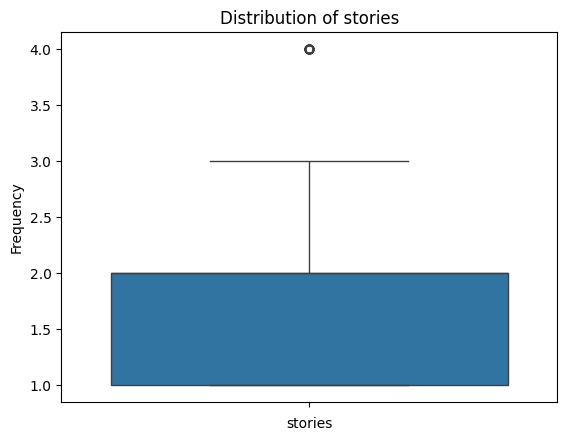

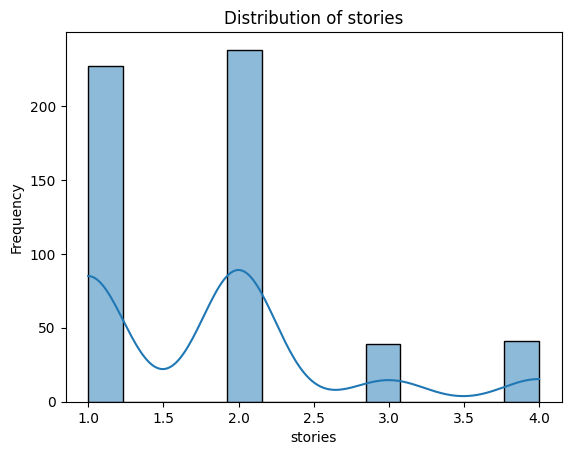

Column: parking, Lower Bound: -1.50, Upper Bound: 2.50
count    545.000000
mean       0.693578
std        0.861586
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: parking, dtype: float64
parking outliers: 2.2%


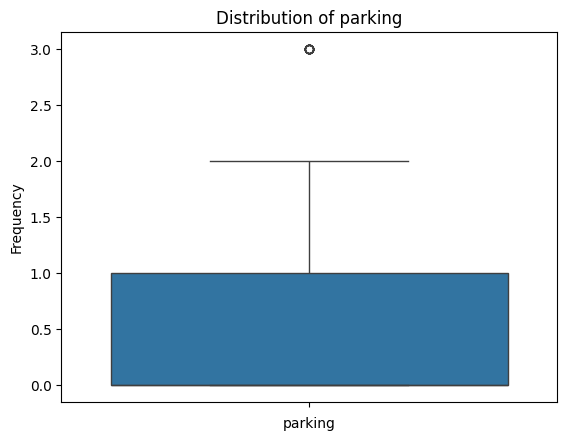

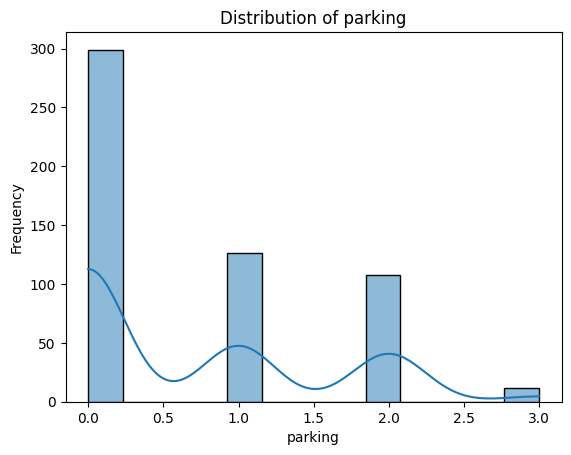

In [51]:
for col in log_transform_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    print(f"Column: {col}, Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(df[col].describe())
    outliers_df = df[df[col] > upper_bound]
    print(f'{col} outliers: {round(len(outliers_df) / len(df) * 100, 2)}%')
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()
    sns.histplot(df[col], kde=True)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()
    

In [52]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [53]:
df['furnishingstatus'].map({'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}).value_counts()

furnishingstatus
1    227
0    178
2    140
Name: count, dtype: int64

In [54]:
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor
import shap
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score,root_mean_squared_error,root_mean_squared_log_error,mean_absolute_error
import statsmodels.api as sm

In [55]:
x = df.drop(['price'], axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)
print(f"Dummy Regressor Score: {dummy_regressor.score(X_test, y_test)}")

Dummy Regressor Score: -0.017925679424830143


In [56]:
X_mi = X_train.copy()

categorical_cols = X_mi.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    X_mi[col] = X_mi[col].astype('category').cat.codes

discrete_mask = X_train.columns.isin(categorical_cols)

mi_scores = mutual_info_regression(
    X_mi,
    y_train.astype('category').cat.codes,
    discrete_features=discrete_mask,
    random_state=42
)
mi_scores = pd.Series(mi_scores, index=X_train.columns)
mi_scores.sort_values(ascending=False, inplace=True)
mi_scores.head(20)

area                0.314923
bathrooms           0.137513
stories             0.136441
guestroom           0.108474
furnishingstatus    0.106054
parking             0.105080
bedrooms            0.102403
airconditioning     0.098507
mainroad            0.095131
basement            0.047365
prefarea            0.043955
hotwaterheating     0.000000
dtype: float64

Training Linear Regression...


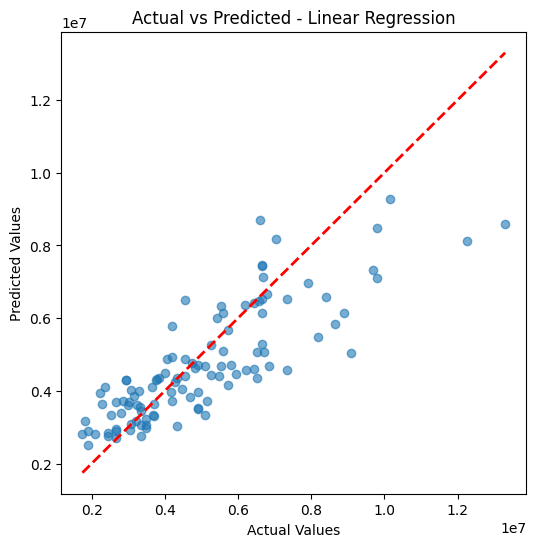

Residual Mean : 302012.2292
Residual Std  : 1296463.4385


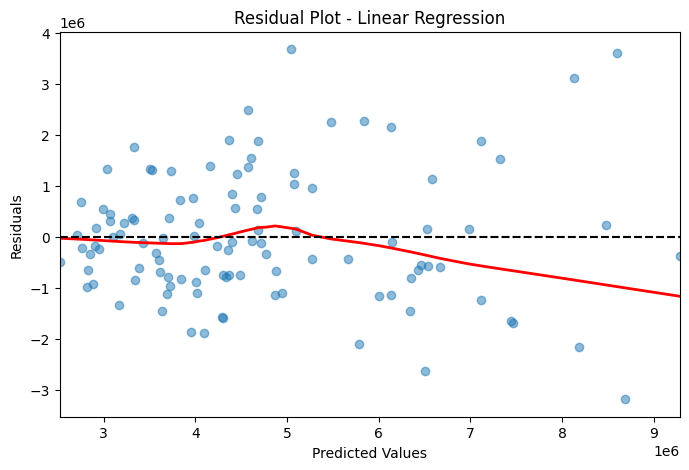

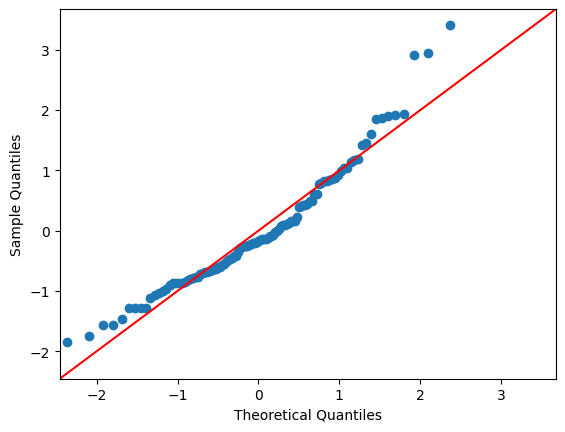

Training Ridge...


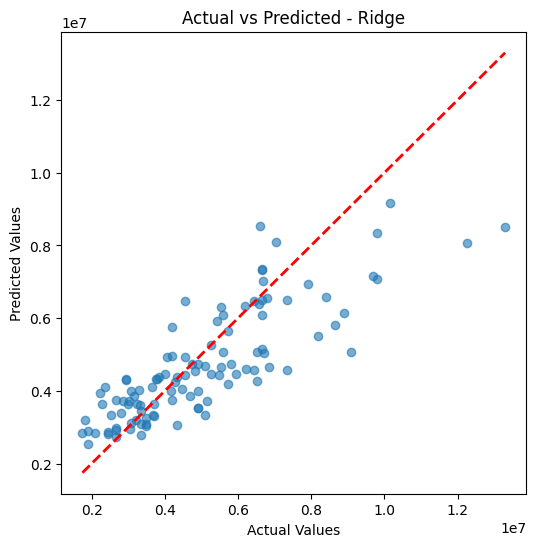

Residual Mean : 310182.7615
Residual Std  : 1303081.1822


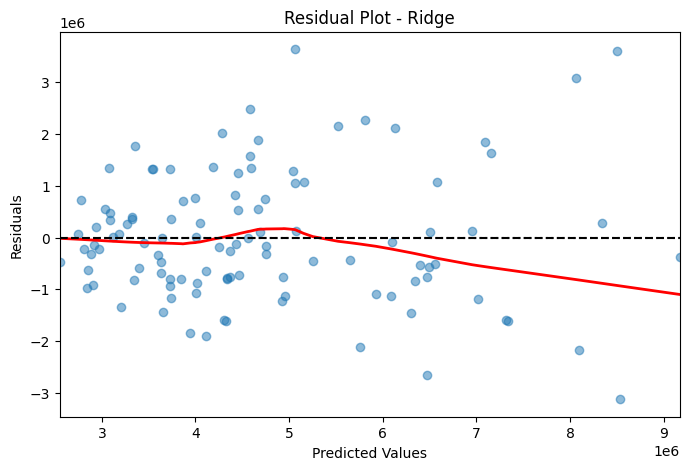

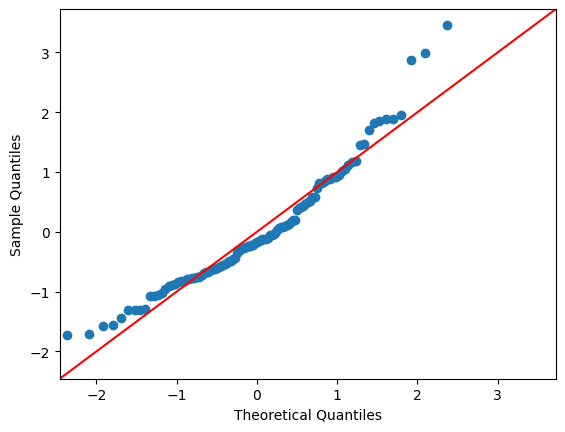

Training Lasso...


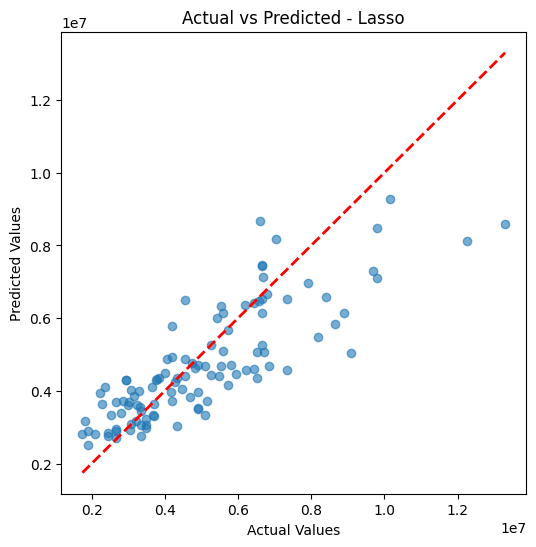

Residual Mean : 302144.3553
Residual Std  : 1296715.0987


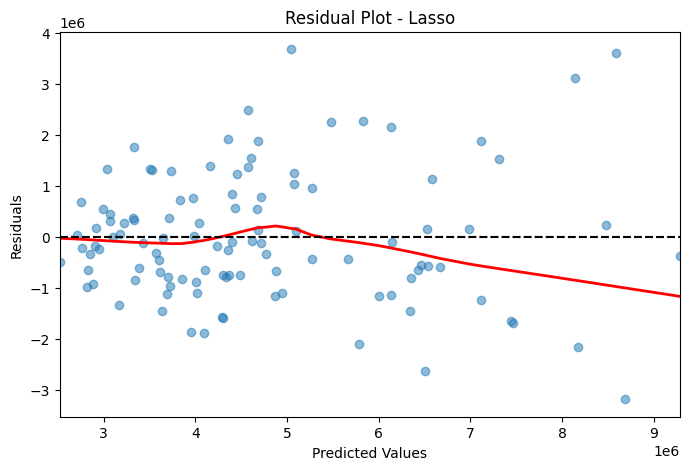

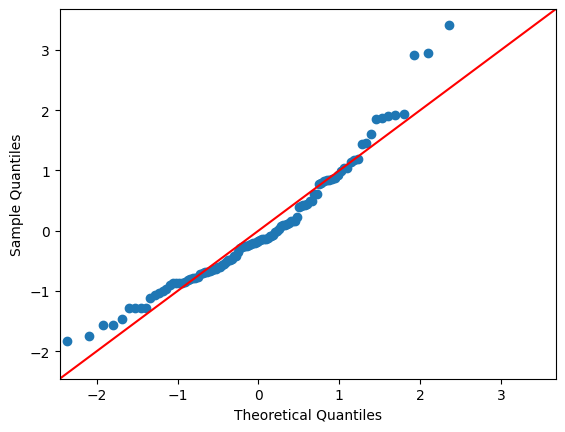

Training ElasticNet...


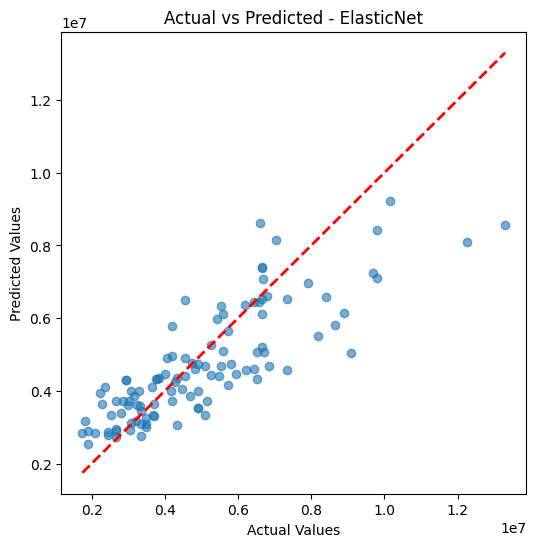

Residual Mean : 305584.4359
Residual Std  : 1299316.4343


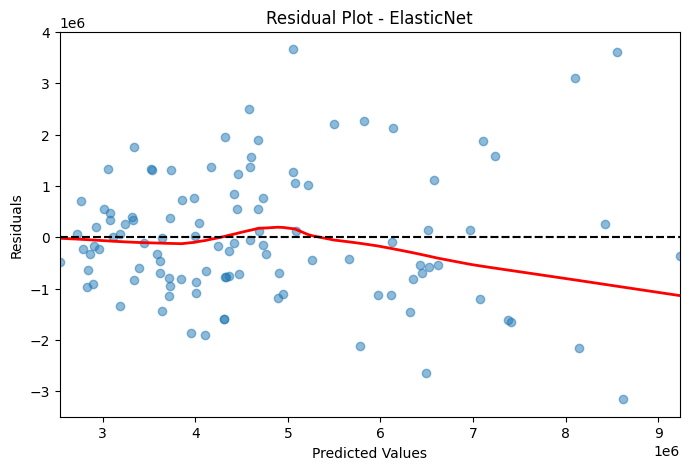

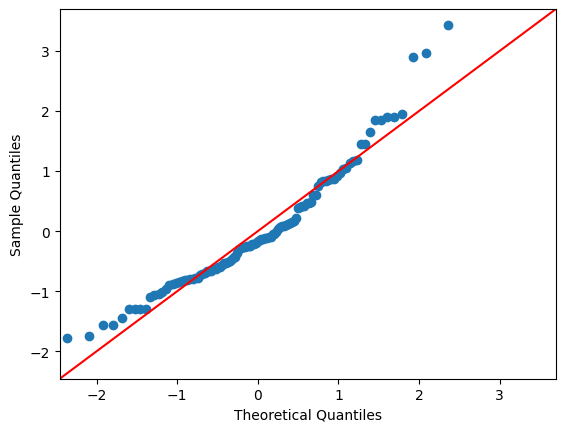

Training Random Forest...


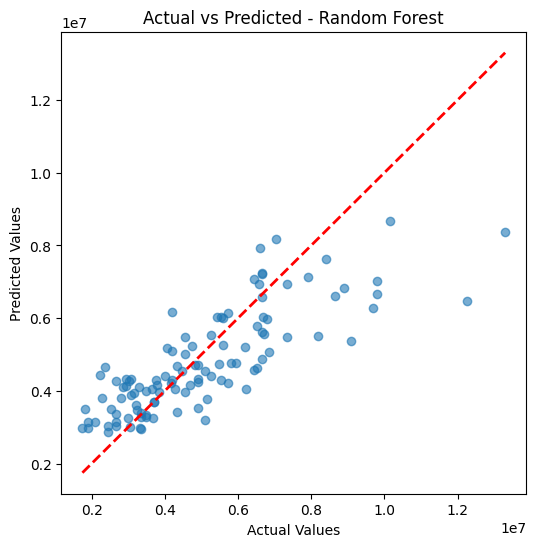

Residual Mean : 225978.9391
Residual Std  : 1392764.5861


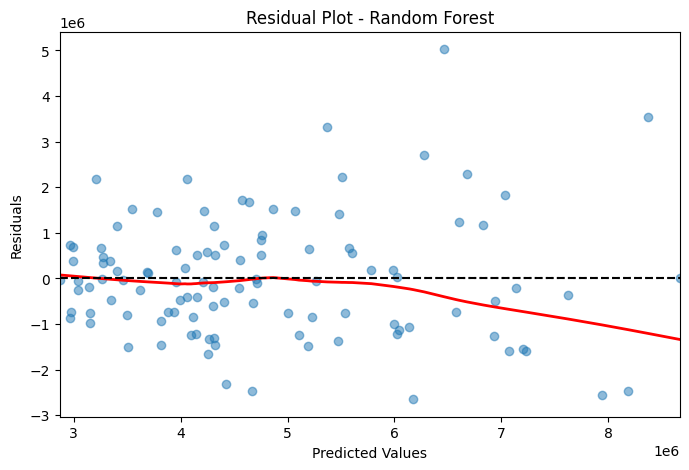

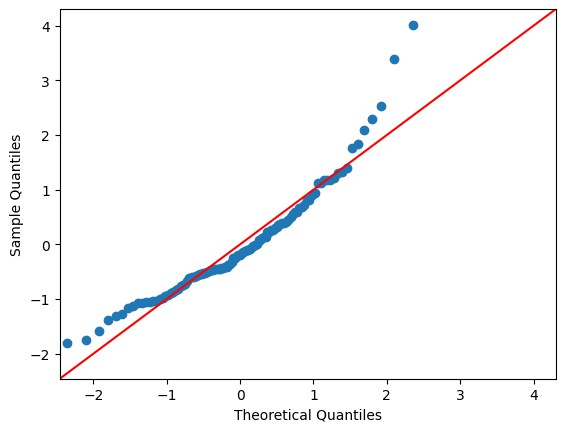

Training XGBoost...


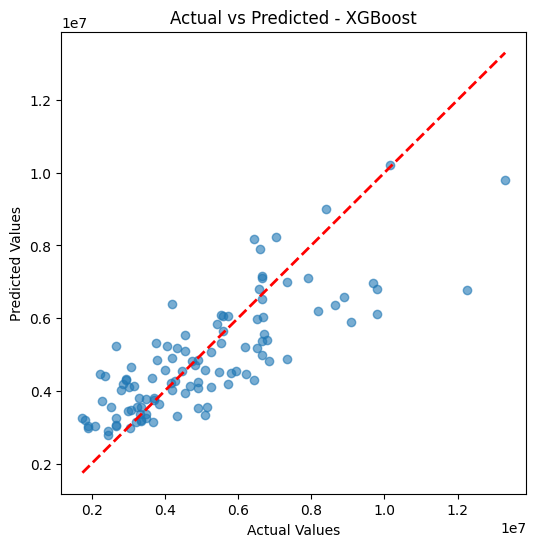

Residual Mean : 158797.3647
Residual Std  : 1375931.1030


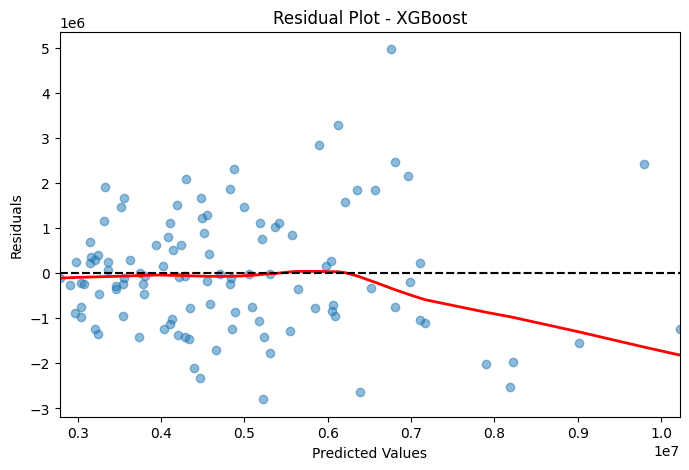

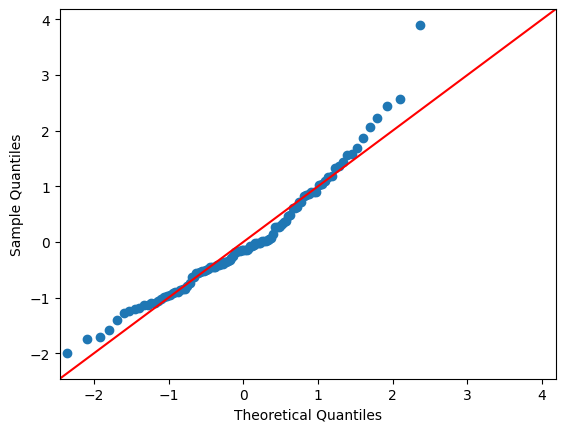

Training LightGBM...


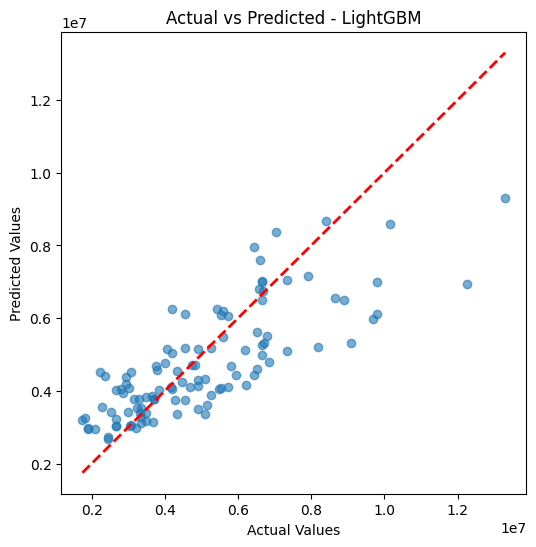

Residual Mean : 269300.6995
Residual Std  : 1404519.1806


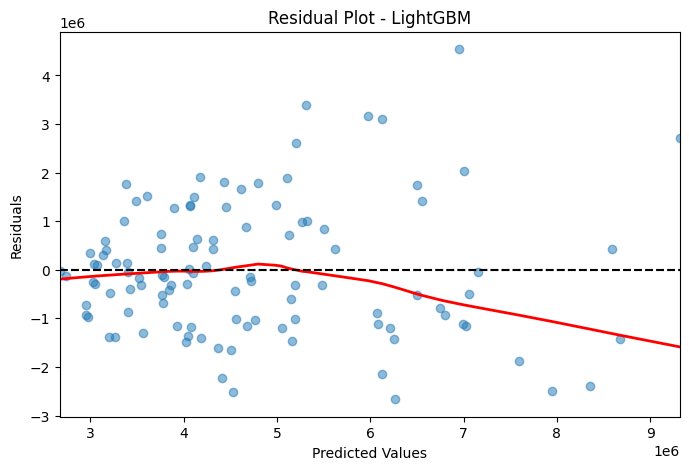

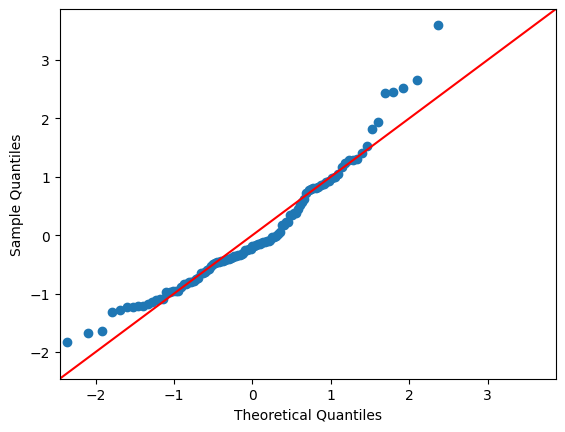

,Model Name,r2 score_train,r2 score_test,Overfitting Gap,root_mean_squared_error,mean_absolute_error,root_mean_squared_log_error
0,Linear Regression,0.681472,0.652471,0.029001,1.325371e+06,9.740995e+05,0.249155
2,Lasso,0.681445,0.652328,0.029118,1.325645e+06,9.743160e+05,0.249202
3,ElasticNet,0.680747,0.650590,0.030157,1.328953e+06,9.765380e+05,0.249767
1,Ridge,0.679630,0.648109,0.031521,1.333663e+06,9.795887e+05,0.250546
5,XGBoost,0.850117,0.623898,0.226219,1.378780e+06,1.025935e+06,0.271343
4,Random Forest,0.888045,0.609648,0.278397,1.404658e+06,1.028049e+06,0.268403
6,LightGBM,0.829914,0.598957,0.230957,1.423762e+06,1.050217e+06,0.271096


In [57]:
log_transform_cols = list(set(log_transform_cols) & set(X_train.columns))

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

for col in log_transform_cols:
    if col in num_cols:
        num_cols.remove(col)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
log_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power_transform', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
        ('log', log_transformer, log_transform_cols)
    ]
)


param_grid_LR = {
    'Regressor__fit_intercept': [True, False],
    'Regressor__positive': [False, True]
}
param_grid_Ridge = {
    'Regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'Regressor__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'sparse_cg', 'lbfgs'],
    'Regressor__fit_intercept': [True, False],
    'Regressor__copy_X': [True, False]
}
param_grid_Lasso = {
    'Regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'Regressor__fit_intercept': [True, False],
    'Regressor__max_iter': [1000, 3000, 5000],
    'Regressor__selection': ['cyclic', 'random'],
    'Regressor__copy_X': [True, False]
}
param_grid_ElasticNet = {
    'Regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'Regressor__l1_ratio': [0.0, 0.2, 0.5, 0.8, 1.0],
    'Regressor__fit_intercept': [True, False],
    'Regressor__max_iter': [1000, 3000, 5000],
    'Regressor__selection': ['cyclic', 'random'],
    'Regressor__copy_X': [True, False]
}
param_grid_RF = {
    'Regressor__n_estimators': [100, 200, 300],
    'Regressor__max_depth': [None, 5, 10, 15, 20,25, 30, 35, 40],
    'Regressor__min_samples_split': [2, 5, 10],
    'Regressor__min_samples_leaf': [1, 2, 4],
    'Regressor__max_features': ['sqrt', 'log2', None],
    'Regressor__bootstrap': [True, False],
    'Regressor__ccp_alpha': [0.0, 0.001, 0.01]
}
param_grid_XGB = {
    'Regressor__n_estimators': [100, 200, 300],
    'Regressor__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'Regressor__max_depth': [3, 5, 7, 9,12,15],
    'Regressor__min_child_weight': [1, 3, 5, 7],
    'Regressor__gamma': [0, 0.1, 0.2, 0.3],
    'Regressor__subsample': [0.8, 0.9, 1.0],
    'Regressor__colsample_bytree': [0.8, 0.9, 1.0],
    'Regressor__reg_alpha': [0, 0.1, 0.5, 1],
    'Regressor__reg_lambda': [0.1, 1, 5, 10],
    'Regressor__tree_method': ['hist'],
    'Regressor__objective': ['reg:squarederror']
}
param_grid_LGBM = {
    'Regressor__num_leaves': [31, 63, 127],
    'Regressor__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'Regressor__n_estimators': [100, 200, 300],
    'Regressor__max_depth': [-1, 3, 6, 9],
    'Regressor__min_child_samples': [10, 20, 30],
    'Regressor__min_child_weight': [1, 5, 9],
    'Regressor__colsample_bytree': [0.8, 0.9, 1.0],
    'Regressor__subsample': [0.8, 0.9, 1.0],
    'Regressor__reg_alpha': [0, 0.1, 0.5, 1],
    'Regressor__reg_lambda': [0.1, 1, 5, 10],
    'Regressor__min_split_gain': [0, 0.1, 0.2],
    'Regressor__bagging_freq': [1, 5]
}

models = {
    'Linear Regression': (
        TransformedTargetRegressor(
            regressor=LinearRegression(),
            transformer=PowerTransformer(method='yeo-johnson')
        ),
        param_grid_LR
    ),

    'Ridge': (
        TransformedTargetRegressor(
            regressor=Ridge(random_state=42),
            transformer=PowerTransformer(method='yeo-johnson')
        ),
        param_grid_Ridge
    ),

    'Lasso': (
        TransformedTargetRegressor(
            regressor=Lasso(random_state=42),
            transformer=PowerTransformer(method='yeo-johnson')
        ),
        param_grid_Lasso
    ),

    'ElasticNet': (
        TransformedTargetRegressor(
            regressor=ElasticNet(random_state=42),
            transformer=PowerTransformer(method='yeo-johnson')
        ),
        param_grid_ElasticNet
    ),

    'Random Forest': (
        RandomForestRegressor(random_state=42),
        param_grid_RF
    ),

    'XGBoost': (
        XGBRegressor(
            objective='reg:squarederror',
            eval_metric='rmse',
            random_state=42
        ),
        param_grid_XGB
    ),

    'LightGBM': (
        LGBMRegressor(
            random_state=42,
            verbose=-1
        ),
        param_grid_LGBM
    )
}
linear_models = ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']
for m_name in linear_models:
    model_obj, p_grid = models[m_name]
    new_p_grid = {param.replace('Regressor__', 'Regressor__regressor__'): values for param, values in p_grid.items()}
    models[m_name] = (model_obj, new_p_grid)

all_models_results = []
saved_pipelines = {}
best_R2_score = -1
best_pipeline = None
for model_name, (model, param_grid) in models.items():
    print(f"Training {model_name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('Regressor', model)])

    if model_name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']:
        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
    else:
        grid_search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=75, cv=5, scoring='r2', n_jobs=-1, random_state=42)

    grid_search.fit(X_train, y_train)

    y_pred_train = grid_search.predict(X_train)
    y_pred_test = grid_search.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    y_pred_test_clip = np.clip(y_pred_test, 0, None)

    if (y_test >= 0).all():
        rmsle_val = root_mean_squared_log_error(
        y_test,
        y_pred_test_clip
        )
    else:
        rmsle_val = np.nan


    all_models_results.append({
        'Model Name': model_name,
        'r2 score_train': r2_train,
        'r2 score_test': r2_test,
        'Overfitting Gap': r2_train - r2_test,
        'root_mean_squared_error': root_mean_squared_error(y_test, y_pred_test),
        'mean_absolute_error': mean_absolute_error(y_test, y_pred_test),
        'root_mean_squared_log_error': rmsle_val
    })
    saved_pipelines[model_name] = grid_search.best_estimator_
    if r2_test > best_R2_score:
        best_R2_score = r2_test
        best_pipeline = grid_search.best_estimator_

    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred_test, alpha=0.6)
    plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
    )
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.show()

    residuals = y_test - y_pred_test
    print(f"Residual Mean : {residuals.mean():.4f}")
    print(f"Residual Std  : {residuals.std():.4f}")

    plt.figure(figsize=(8,5))
    sns.residplot(
    x=y_pred_test,
    y=residuals,
    lowess=True,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red', 'lw':2}
    )
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot - {model_name}")
    plt.show()

    sm.qqplot(residuals, line='45', fit=True)
    plt.show()

report_df = pd.DataFrame(all_models_results).sort_values('r2 score_test', ascending=False)
report_df

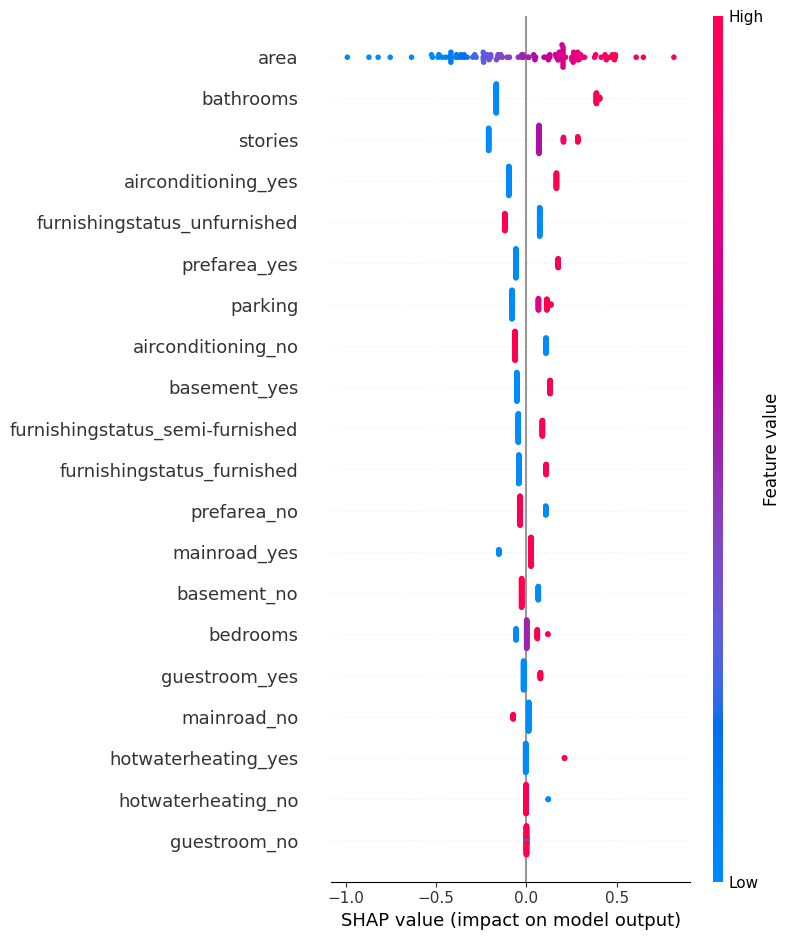

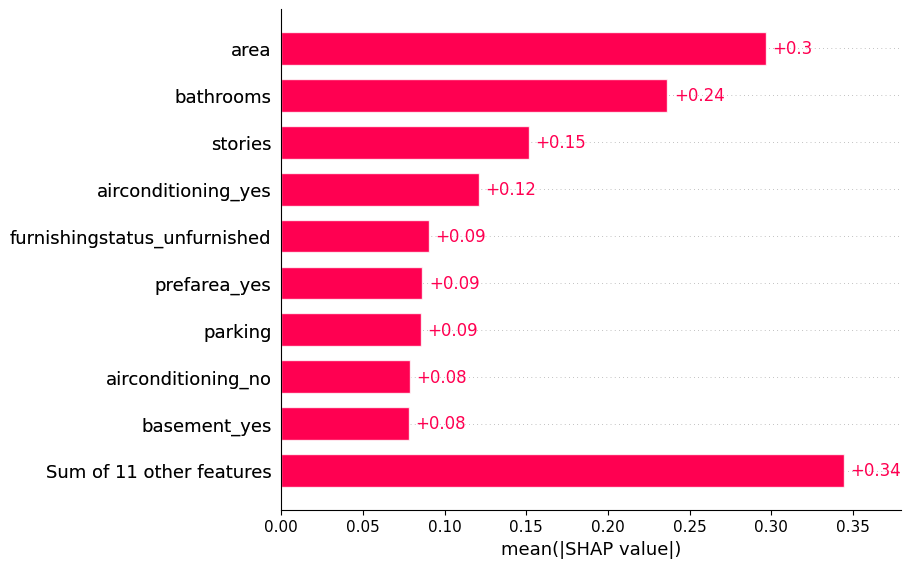

In [73]:
best_model_step = best_pipeline.named_steps["Regressor"]
preprocessor = best_pipeline.named_steps["preprocessor"]

if hasattr(best_model_step, "regressor_"):
    model = best_model_step.regressor_
elif hasattr(best_model_step, "regressor"):
    model = best_model_step.regressor
else:
    model = best_model_step


X_test_transformed = preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()



feature_names = preprocessor.get_feature_names_out()
feature_names = [
    feature.split("__", 1)[1]
    for feature in feature_names
]

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)



sample_size = min(300, len(X_test_transformed))

X_shap = X_test_transformed.sample(
    sample_size,
    random_state=42
)



if isinstance(
    model,
    (
        RandomForestRegressor,
        XGBRegressor,
        LGBMRegressor
    )
):

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_shap)

elif isinstance(
    model,
    (
        LinearRegression,
        Ridge,
        Lasso,
        ElasticNet
    )
):

    explainer = shap.Explainer(model, X_shap)
    shap_values = explainer(X_shap)

else:

    explainer = shap.Explainer(model.predict, X_shap)
    shap_values = explainer(X_shap)



shap.summary_plot(
    shap_values,
    X_shap
)

shap.plots.bar(shap_values)

In [74]:
report_df.to_csv('hotel_models_comparison_leaderboard.csv', index=False)
print("Leaderboard saved successfully!")

Leaderboard saved successfully!
